# Setup

### Installations

In [ ]:
!pip install ucimlrepo
!pip install aif360
!pip install sklearn

  Using cached sklearn-0.0.post12.tar.gz (2.6 kB)
  error: subprocess-exited-with-error
  
  × python setup.py egg_info did not run successfully.
  │ exit code: 1
  ╰─> See above for output.
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
  Preparing metadata (setup.py) ... error
error: metadata-generation-failed

× Encountered error while generating package metadata.
╰─> See above for output.

note: This is an issue with the package mentioned above, not pip.
hint: See above for details.


### Library imports

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from ucimlrepo import fetch_ucirepo
from sklearn.linear_model import LogisticRegression
import re
from sklearn.ensemble import RandomForestClassifier
from scipy import stats
from scipy.stats import pearsonr
from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder
from sklearn.model_selection import cross_validate, StratifiedKFold, train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, StackingClassifier
from sklearn.metrics import (
    make_scorer, accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay, roc_curve, roc_auc_score
)
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from aif360.sklearn.metrics import statistical_parity_difference
from aif360.algorithms.preprocessing.reweighing import Reweighing
from aif360.algorithms.postprocessing import CalibratedEqOddsPostprocessing
from aif360.metrics import BinaryLabelDatasetMetric
from aif360.datasets import BinaryLabelDataset

## Fetching the dataset

In [ ]:
# fetch dataset
predict_students_dropout_and_academic_success = fetch_ucirepo(id=697)

# data (as pandas dataframes)
X = predict_students_dropout_and_academic_success.data.features
y = predict_students_dropout_and_academic_success.data.targets

# merging features with target column
df = pd.concat([X, y], axis=1)
df.rename(columns={df.columns[-1]: "target"}, inplace=True)

# string mapping for integer categorical values for result interpretation
categorical_value_maps = {
    "Daytime/evening attendance" : {
        0: "evening",
        1: "daytime"
    },
    "Gender": {
        1: "male",
        0: "female",
    },
    "Scholarship holder": {
        1: "yes",
        0: "no",
    },
    "Educational special needs": {
        1: "yes",
        0: "no",
    },
    "Tuition fees up to date": {
        1: "yes",
        0: "no",
    },
    "Displaced": {
        1: "yes",
        0: "no",
    },
    "International": {
        1: "yes",
        0: "no",
    },
    "Marital Status": {
        1: "single", 2: "married", 3: "widower", 4: "divorced",
        5: "facto union", 6: "legally separated"
    },
    "Application mode": {
        1: "1st phase - general contingent",
        2: "Ordinance No. 612/93",
        5: "1st phase - special contingent (Azores Island)",
        7: "Holders of other higher courses",
        10: "Ordinance No. 854-B/99",
        15: "International student (bachelor)",
        16: "1st phase - special contingent (Madeira Island)",
        17: "2nd phase - general contingent",
        18: "3rd phase - general contingent",
        26: "Ordinance No. 533-A/99, item b2 (Different Plan)",
        27: "Ordinance No. 533-A/99, item b3 (Other Institution)",
        39: "Over 23 years old",
        42: "Transfer",
        43: "Change of course",
        44: "Technological specialization diploma holders",
        51: "Change of institution/course",
        53: "Short cycle diploma holders",
        57: "Change of institution/course (International)"
    },
    "Course": {
        33: "Biofuel Production Technologies",
        171: "Animation and Multimedia Design",
        8014: "Social Service (evening attendance)",
        9003: "Agronomy",
        9070: "Communication Design",
        9085: "Veterinary Nursing",
        9119: "Informatics Engineering",
        9130: "Equinculture",
        9147: "Management",
        9238: "Social Service",
        9254: "Tourism",
        9500: "Nursing",
        9556: "Oral Hygiene",
        9670: "Advertising and Marketing Management",
        9773: "Journalism and Communication",
        9853: "Basic Education",
        9991: "Management (evening attendance)"
    },
    "Previous qualification": {
        1: "Secondary education",
        2: "Higher education - bachelor's degree",
        3: "Higher education - degree",
        4: "Higher education - master's",
        5: "Higher education - doctorate",
        6: "Frequency of higher education",
        9: "12th year of schooling - not completed",
        10: "11th year of schooling - not completed",
        12: "Other - 11th year of schooling",
        14: "10th year of schooling",
        15: "10th year of schooling - not completed",
        19: "Basic education 3rd cycle (9th/10th/11th year) or equiv.",
        38: "Basic education 2nd cycle (6th/7th/8th year) or equiv.",
        39: "Technological specialization course",
        40: "Higher education - degree (1st cycle)",
        42: "Professional higher technical course",
        43: "Higher education - master (2nd cycle)"
    },
    "Nacionality": {
        1: "Portuguese", 2: "German", 6: "Spanish", 11: "Italian", 13: "Dutch",
        14: "English", 17: "Lithuanian", 21: "Angolan", 22: "Cape Verdean",
        24: "Guinean", 25: "Mozambican", 26: "Santomean", 32: "Turkish",
        41: "Brazilian", 62: "Romanian", 100: "Moldova (Republic of)",
        101: "Mexican", 103: "Ukrainian", 105: "Russian", 108: "Cuban", 109: "Colombian"
    },
    "Mother's qualification": {
        1: "Secondary Education - 12th Year or Eq.",
        2: "Higher Education - Bachelor's Degree",
        3: "Higher Education - Degree",
        4: "Higher Education - Master's",
        5: "Higher Education - Doctorate",
        6: "Frequency of Higher Education",
        9: "12th Year of Schooling - Not Completed",
        10: "11th Year of Schooling - Not Completed",
        11: "7th Year (Old)",
        12: "Other - 11th Year of Schooling",
        14: "10th Year of Schooling",
        18: "General commerce course",
        19: "Basic Education 3rd Cycle or Equiv.",
        22: "Technical-professional course",
        26: "7th year of schooling",
        27: "2nd cycle of general high school",
        29: "9th Year - Not Completed",
        30: "8th Year",
        34: "Unknown",
        35: "Can't read or write",
        36: "Can read without 4th year of schooling",
        37: "Basic education 1st cycle",
        38: "Basic Education 2nd Cycle",
        39: "Technological specialization course",
        40: "Higher education - degree (1st cycle)",
        41: "Specialized higher studies course",
        42: "Professional higher technical course",
        43: "Higher Education - Master (2nd cycle)",
        44: "Higher Education - Doctorate (3rd cycle)"
    },
    "Mother's occupation": {
        0: "Student",
        1: "Legislative/Executive managers",
        2: "Intellectual/Scientific specialists",
        3: "Intermediate Technicians",
        4: "Administrative staff",
        5: "Personal services / sellers",
        6: "Farmers / skilled workers",
        7: "Skilled workers in industry",
        8: "Installation / machine operators",
        9: "Unskilled workers",
        10: "Armed forces",
        90: "Other situation",
        99: "(blank)",
        122: "Health professionals",
        123: "Teachers",
        125: "ICT specialists",
        131: "Intermediate science/engineering tech",
        132: "Intermediate health tech",
        134: "Legal/social/sports/cultural technicians",
        141: "Office/data processing workers",
        143: "Accounting/statistical operators",
        144: "Other administrative support",
        151: "Personal service workers",
        152: "Sellers",
        153: "Personal care workers",
        171: "Skilled construction workers",
        173: "Printing/precision/jewelers/artisans",
        175: "Food/wood/clothing industry workers",
        191: "Cleaning workers",
        192: "Unskilled agriculture/fisheries",
        193: "Unskilled extractive/manufacturing",
        194: "Meal prep assistants"
    },
        "Father's occupation": {
        0: "Student",
        1: "Legislative/Executive managers",
        2: "Intellectual/Scientific specialists",
        3: "Intermediate Technicians",
        4: "Administrative staff",
        5: "Personal Services / Security / Sellers",
        6: "Farmers / Skilled workers in Agriculture, Fisheries, Forestry",
        7: "Skilled workers in Industry, Construction, Craftsmen",
        8: "Installation / Machine operators / Assembly workers",
        9: "Unskilled Workers",
        10: "Armed Forces Professions",
        90: "Other Situation",
        99: "(blank)",
        101: "Armed Forces Officers",
        102: "Armed Forces Sergeants",
        103: "Other Armed Forces personnel",
        112: "Directors of administrative and commercial services",
        114: "Hotel, catering, trade and other services directors",
        121: "Specialists in physical sciences, mathematics, engineering",
        122: "Health professionals",
        123: "Teachers",
        124: "Specialists in finance, accounting, administration, public/commercial relations",
        131: "Intermediate level science/engineering technicians",
        132: "Technicians and professionals, intermediate level of health",
        134: "Intermediate technicians from legal, social, sports, cultural services",
        135: "Information and communication technology technicians",
        141: "Office workers, secretaries, data processing operators",
        143: "Data, accounting, statistical, financial services operators",
        144: "Other administrative support staff",
        151: "Personal service workers",
        152: "Sellers",
        153: "Personal care workers",
        154: "Protection and security services personnel",
        161: "Market-oriented farmers / skilled agricultural/animal production workers",
        163: "Farmers, livestock keepers, fishermen, hunters, subsistence",
        171: "Skilled construction workers, except electricians",
        172: "Skilled workers in metallurgy, metalworking, similar",
        174: "Skilled workers in electricity and electronics",
        175: "Workers in food processing, woodworking, clothing, other industries",
        181: "Fixed plant and machine operators",
        182: "Assembly workers",
        183: "Vehicle drivers and mobile equipment operators",
        192: "Unskilled workers in agriculture, animal production, fisheries, forestry",
        193: "Unskilled workers in extractive, construction, manufacturing, transport",
        194: "Meal preparation assistants",
        195: "Street vendors / street service providers"
    },
     "Father's qualification": {
        1: "Secondary Education - 12th Year or Eq.",
        2: "Higher Education - Bachelor's Degree",
        3: "Higher Education - Degree",
        4: "Higher Education - Master's",
        5: "Higher Education - Doctorate",
        6: "Frequency of Higher Education",
        9: "12th Year of Schooling - Not Completed",
        10: "11th Year of Schooling - Not Completed",
        11: "7th Year (Old)",
        12: "Other - 11th Year of Schooling",
        13: "2nd year complementary high school course",
        14: "10th Year of Schooling",
        18: "General commerce course",
        19: "Basic Education 3rd Cycle or Equiv.",
        20: "Complementary High School Course",
        22: "Technical-professional course",
        25: "Complementary High School Course - not concluded",
        26: "7th year of schooling",
        27: "2nd cycle of general high school course",
        29: "9th Year of Schooling - Not Completed",
        30: "8th year of schooling",
        31: "General Course of Administration and Commerce",
        33: "Supplementary Accounting and Administration",
        34: "Unknown",
        35: "Can't read or write",
        36: "Can read without 4th year of schooling",
        37: "Basic education 1st cycle (4th/5th year) or equiv.",
        38: "Basic Education 2nd Cycle (6th/7th/8th Year) or Equiv.",
        39: "Technological specialization course",
        40: "Higher education - degree (1st cycle)",
        41: "Specialized higher studies course",
        42: "Professional higher technical course",
        43: "Higher Education - Master (2nd cycle)",
        44: "Higher Education - Doctorate (3rd cycle)"
    }
}

# Data exploration

### Correlations

Checking for correlations between different variables to see whether some of the sensitive values have strong proxies in the dataset.

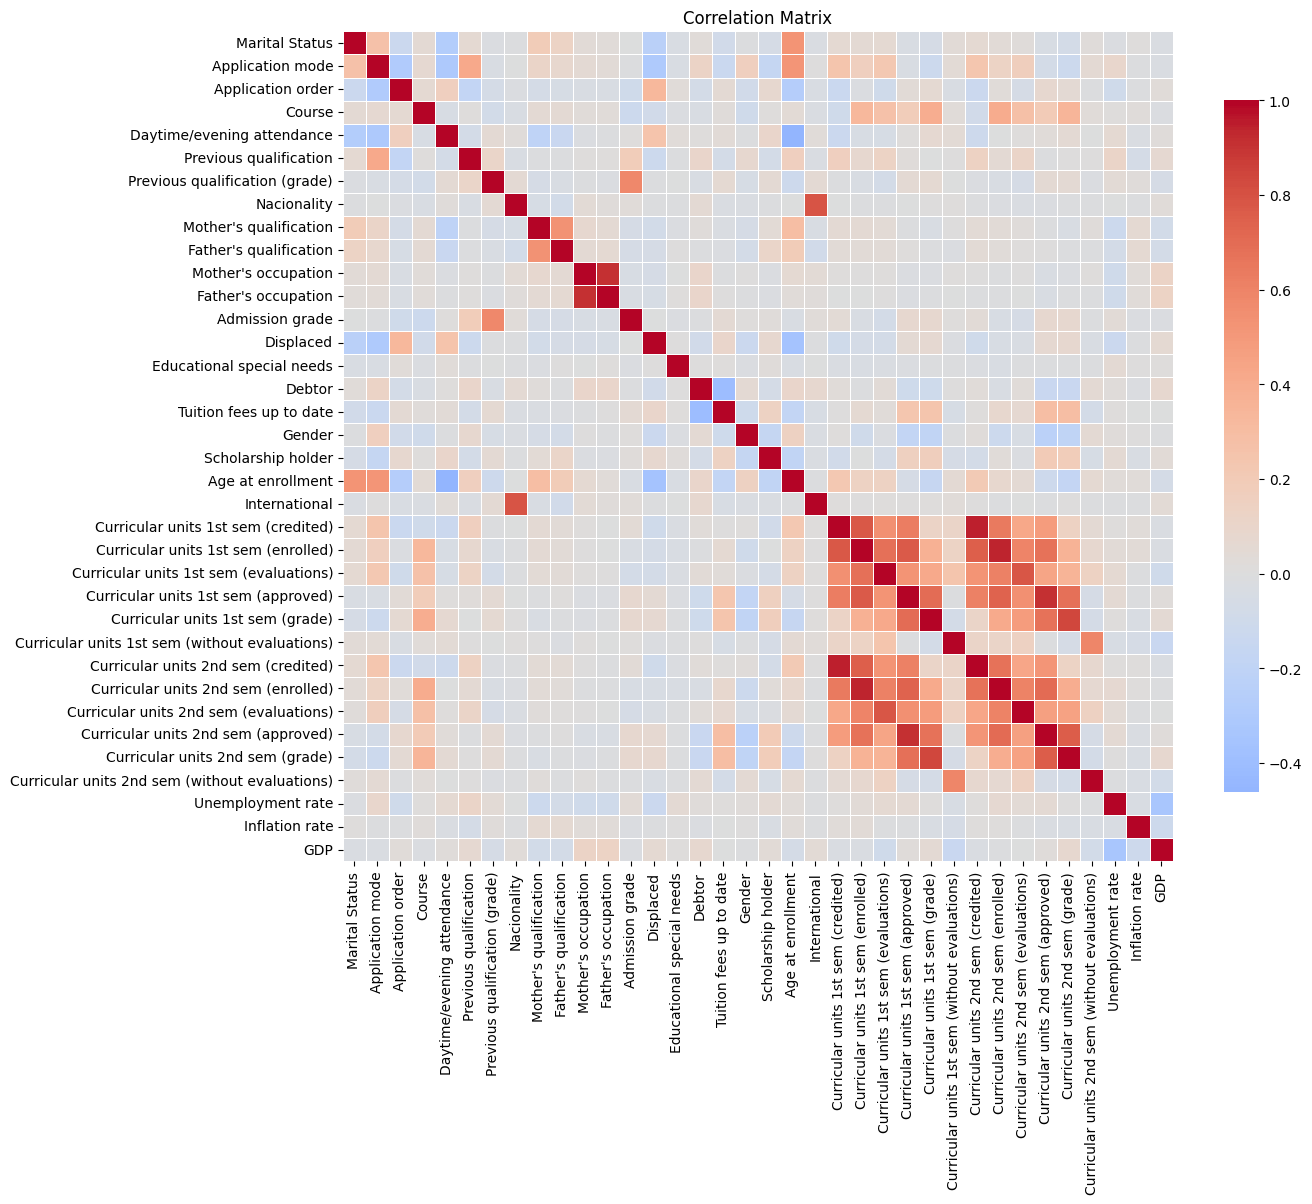

In [ ]:
corr = df.corr(numeric_only=True)

plt.figure(figsize=(14, 12))
sns.heatmap(
    corr,
    cmap="coolwarm",
    center=0,
    square=True,
    linewidths=0.5,
    cbar_kws={"shrink": 0.8}
)
plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()

In [ ]:
alpha = 0.05
threshold = 0.3

num_df = df.select_dtypes(include=[np.number])
cols = num_df.columns

rows = []
for i in range(len(cols)):
    for j in range(i + 1, len(cols)):
        r, p = pearsonr(num_df[cols[i]], num_df[cols[j]])
        if abs(r) >= threshold and p < alpha:
            rows.append({
                "var_1": cols[i],
                "var_2": cols[j],
                "correlation": r,
                "p_value": p
            })

significant_pairs = (
    pd.DataFrame(rows)
    .sort_values(by="correlation", key=np.abs, ascending=False)
)

significant_pairs

,var_1,var_2,correlation,p_value
20,Curricular units 1st sem (credited),Curricular units 2nd sem (credited),0.944811,0.000000e+00
28,Curricular units 1st sem (enrolled),Curricular units 2nd sem (enrolled),0.942627,0.000000e+00
14,Mother's occupation,Father's occupation,0.910472,0.000000e+00
43,Curricular units 1st sem (approved),Curricular units 2nd sem (approved),0.904002,0.000000e+00
48,Curricular units 1st sem (grade),Curricular units 2nd sem (grade),0.837170,0.000000e+00
12,Nacionality,International,0.790935,0.000000e+00
36,Curricular units 1st sem (evaluations),Curricular units 2nd sem (evaluations),0.778863,0.000000e+00
17,Curricular units 1st sem (credited),Curricular units 1st sem (enrolled),0.774344,0.000000e+00
25,Curricular units 1st sem (enrolled),Curricular units 1st sem (approved),0.769083,0.000000e+00
58,Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),0.760804,0.000000e+00


In [ ]:
# Socio-economic data
demographic_cols = [
     "Gender", "Marital Status", "Age at enrollment",
     "International", "Scholarship holder",
    "Mother's qualification", "Father's qualification",
    "Mother's occupation", "Father's occupation",
    "Displaced", "Educational special needs", "Debtor",
    "Tuition fees up to date"
]

# Enrollment & Program Info
enroll_cols = [
    "Application mode", "Application order", "Course",
    "Daytime/evening attendance", "Admission grade"
]

# 1st Semester Performance
sem1_cols = [
    "Curricular units 1st sem (credited)",
    "Curricular units 1st sem (enrolled)",
    "Curricular units 1st sem (evaluations)",
    "Curricular units 1st sem (approved)",
    "Curricular units 1st sem (grade)",
    "Curricular units 1st sem (without evaluations)"
]

# 2nd Semester Performance
sem2_cols = [
    "Curricular units 2nd sem (credited)",
    "Curricular units 2nd sem (enrolled)",
    "Curricular units 2nd sem (evaluations)",
    "Curricular units 2nd sem (approved)",
    "Curricular units 2nd sem (grade)",
    "Curricular units 2nd sem (without evaluations)"
]

# Macroeconomic Context
macro_cols = ["Unemployment rate", "Inflation rate", "GDP"]

## Checking for group imbalances / minorities

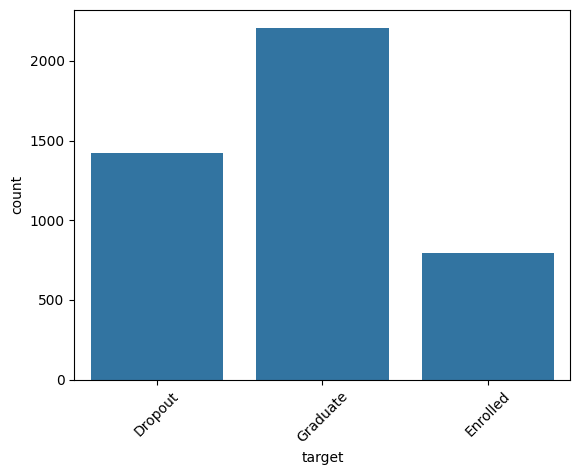

In [ ]:
# class counts
df["target"].value_counts()
sns.countplot(data=df, x="target")
plt.xticks(rotation=45)
plt.show()

In [ ]:

def plot_categories(cols):
  n_cols = 3
  n_rows = int(np.ceil(len(cols) / n_cols))

  fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, n_rows * 6))
  axes = axes.flatten()

  MAX_CATS = 10

  for ax, c in zip(axes, cols):
      # Map integer codes to strings
      if c in categorical_value_maps:
          mapped_col = df[c].map(categorical_value_maps[c])
      else:
          mapped_col = df[c]

      # Limit number of categories for readability
      if mapped_col.nunique() > MAX_CATS:
          top = mapped_col.value_counts().nlargest(MAX_CATS).index
          plot_col = mapped_col.where(mapped_col.isin(top), "Other")
      else:
          plot_col = mapped_col

      plot_col = plot_col.astype(str)
      plot_col = plot_col.str.slice(0,10)

      sns.countplot(x=plot_col, hue=df["target"], ax=ax)
      ax.tick_params(axis="x", rotation=45)
      ax.set_title(f"{c} by target")

  # Hide unused axes
  for ax in axes[len(cols):]:
      ax.set_visible(False)

  plt.tight_layout()
  plt.show()

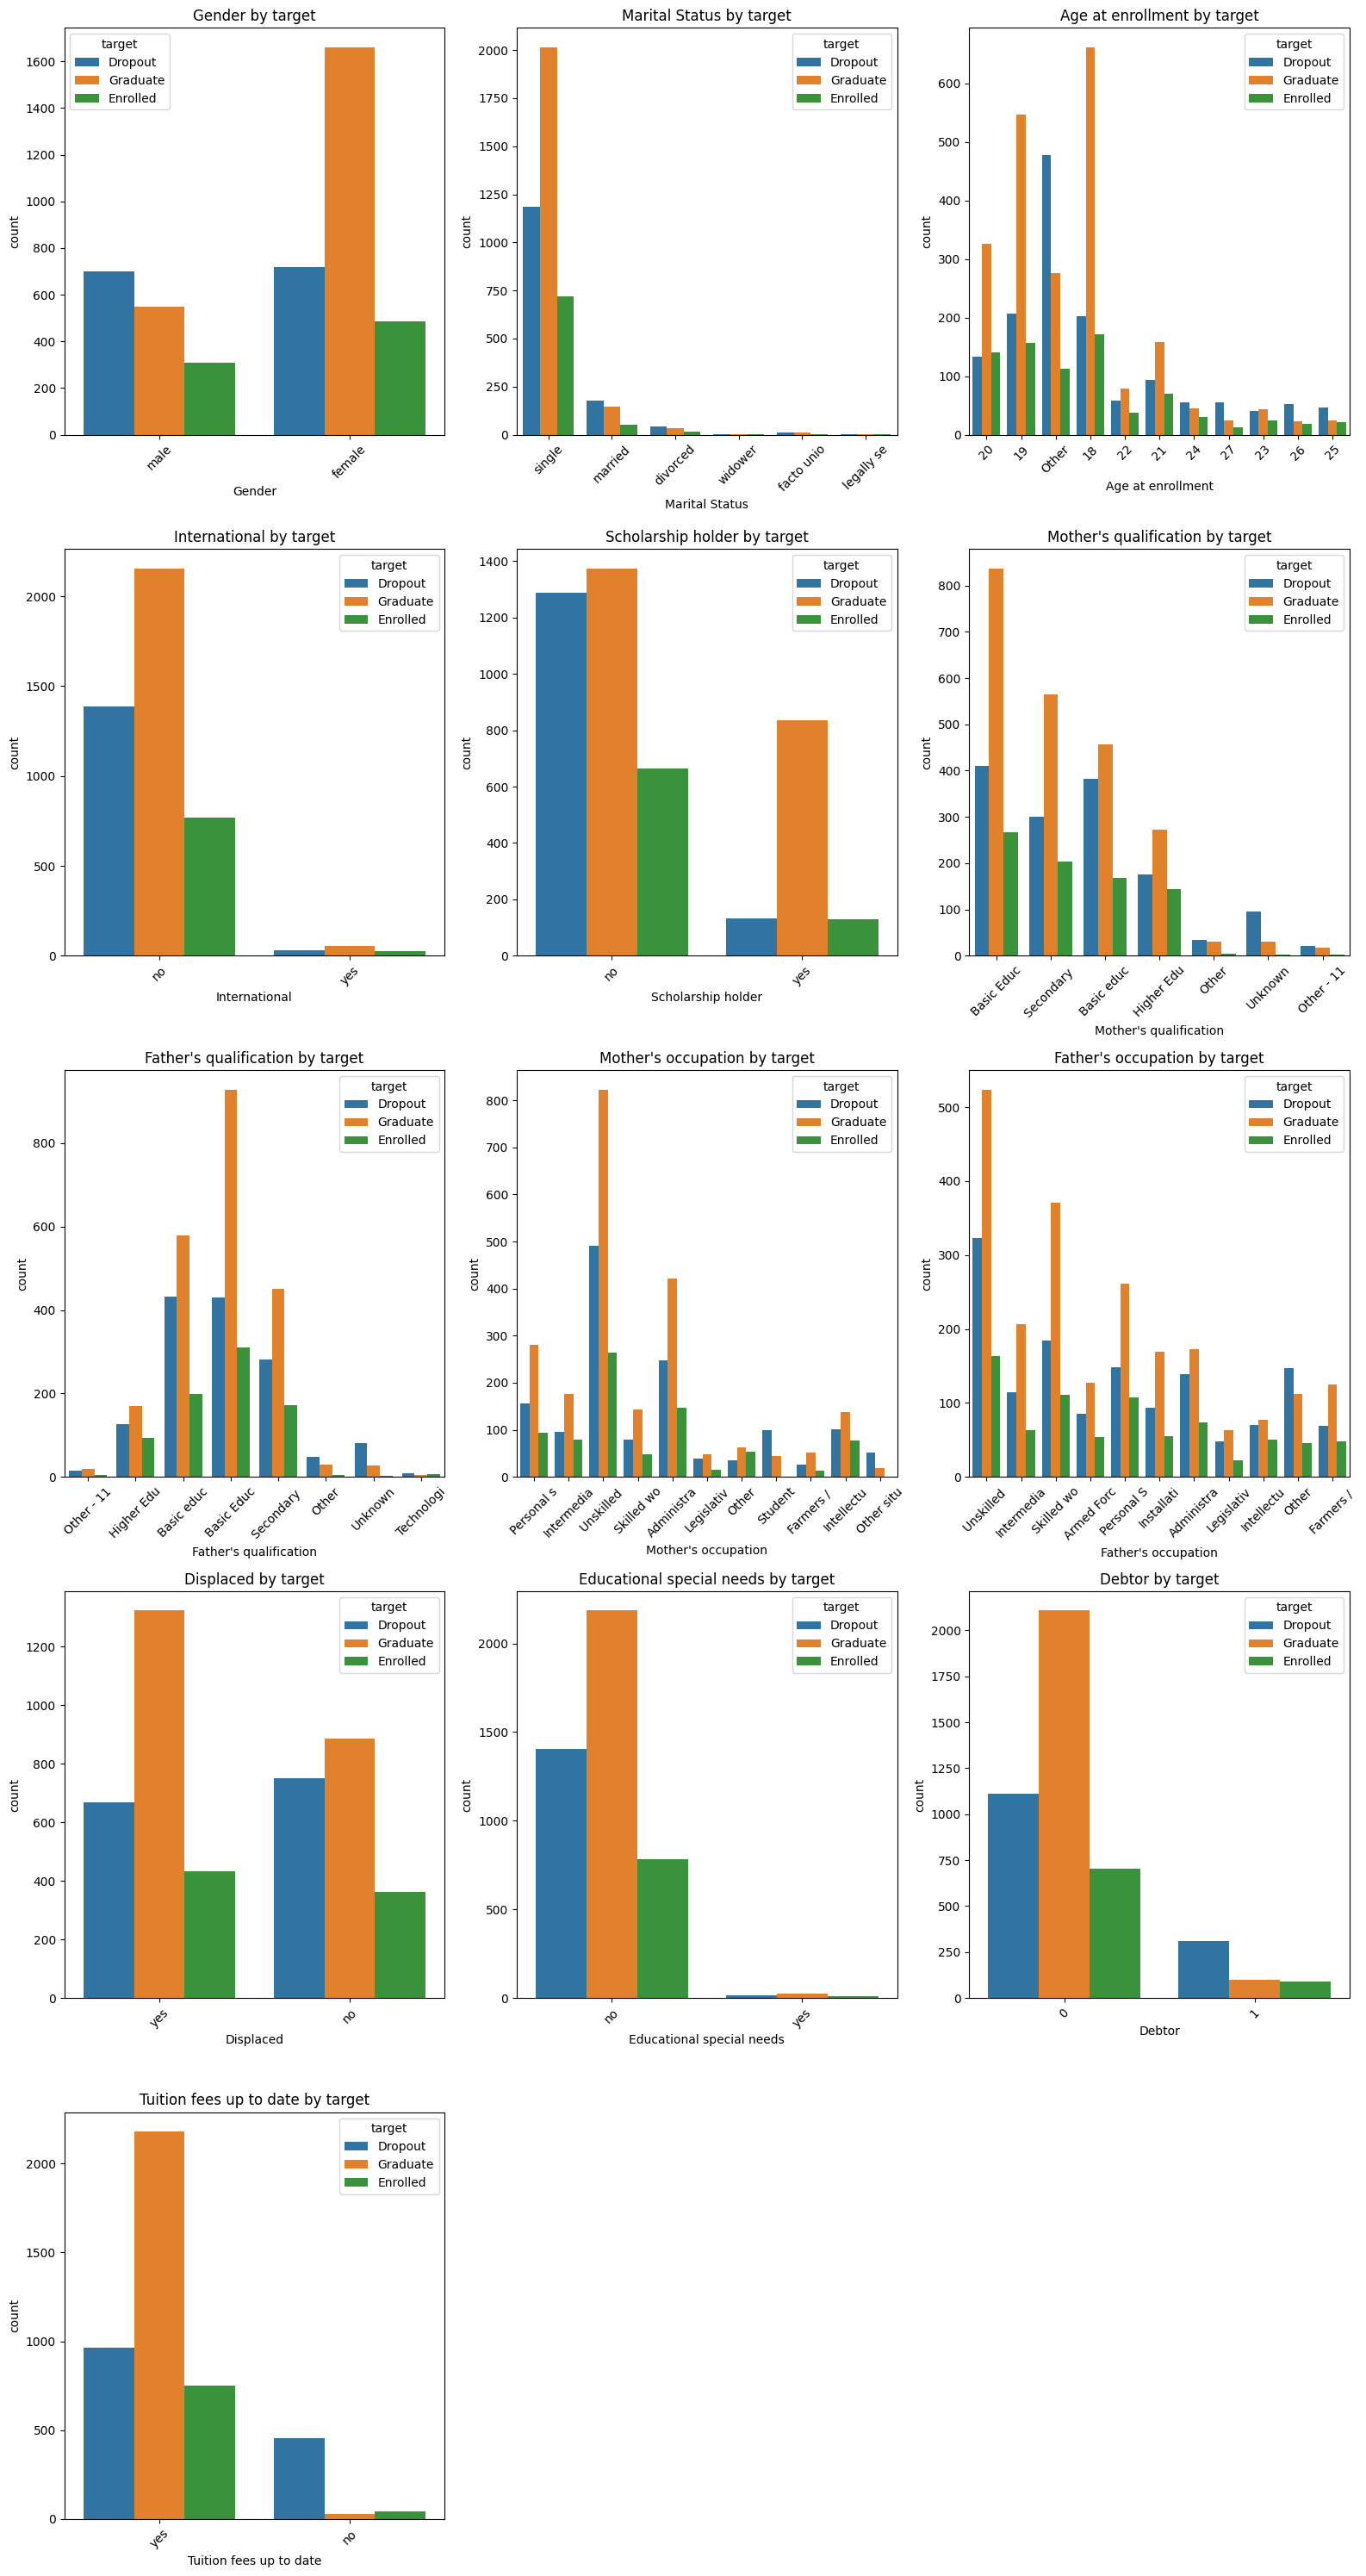

In [ ]:
plot_categories(demographic_cols)

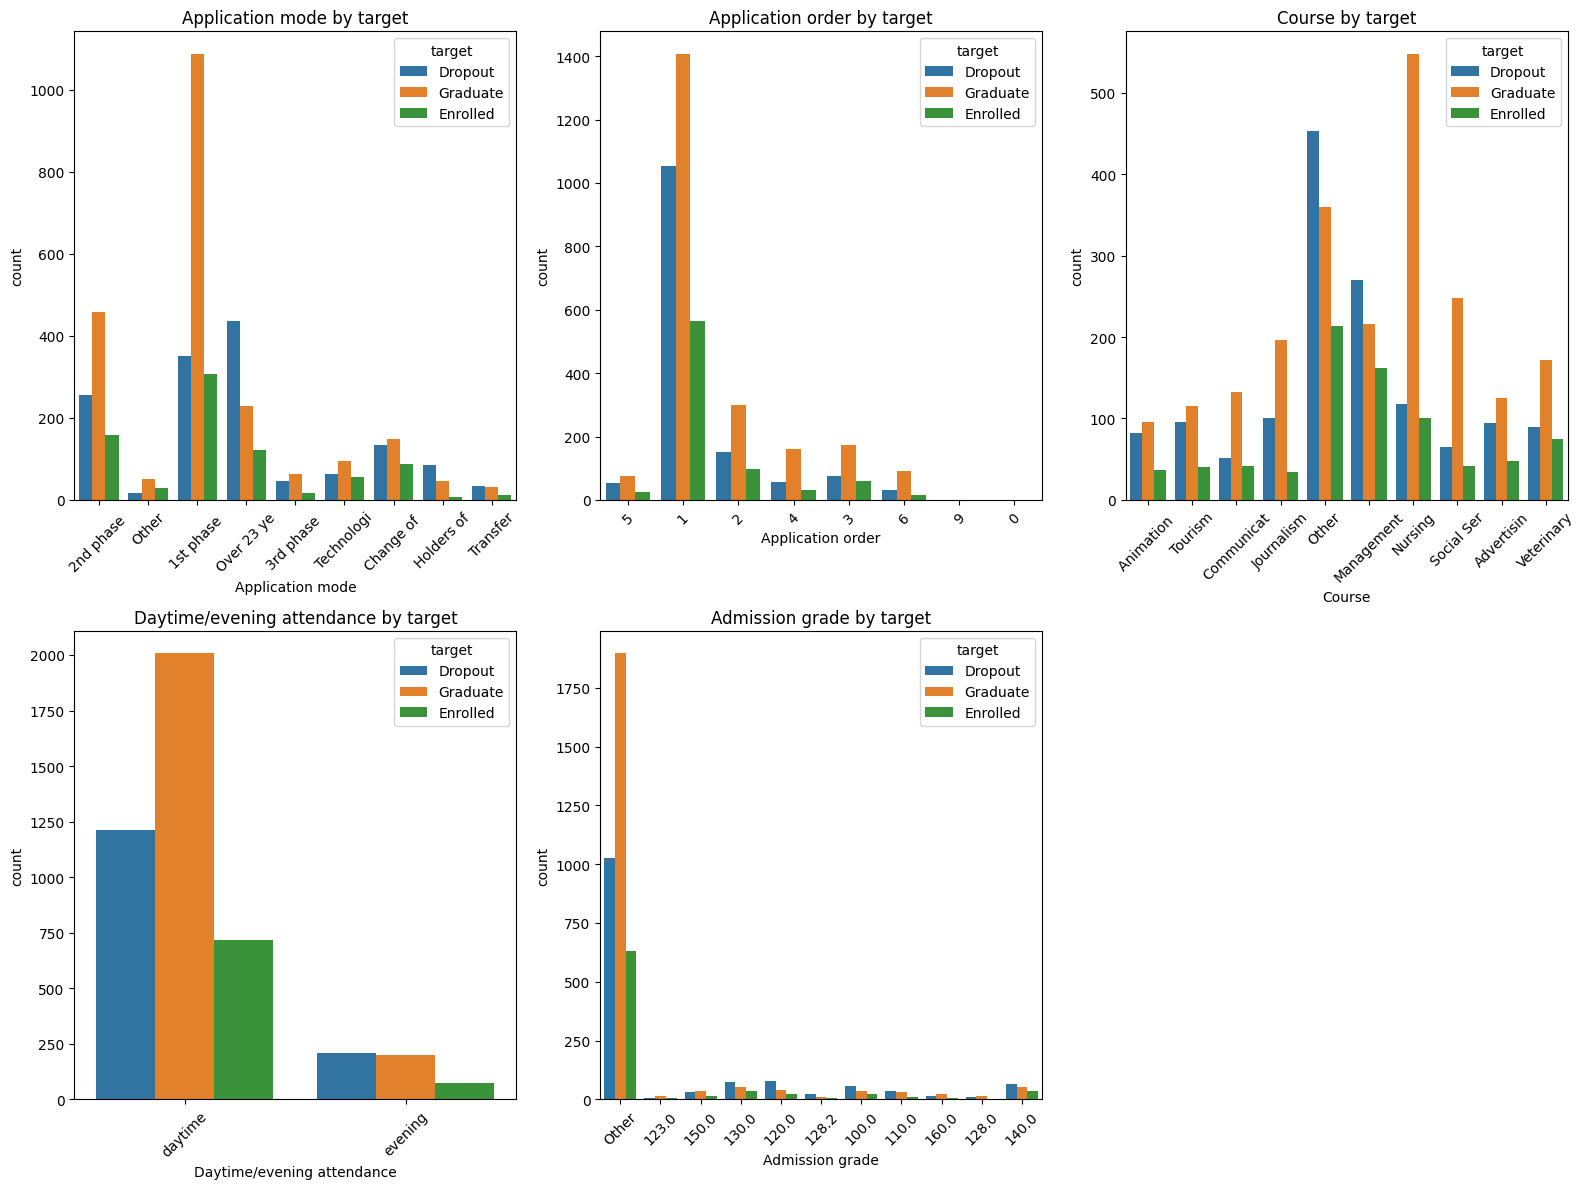

In [ ]:
plot_categories(enroll_cols)

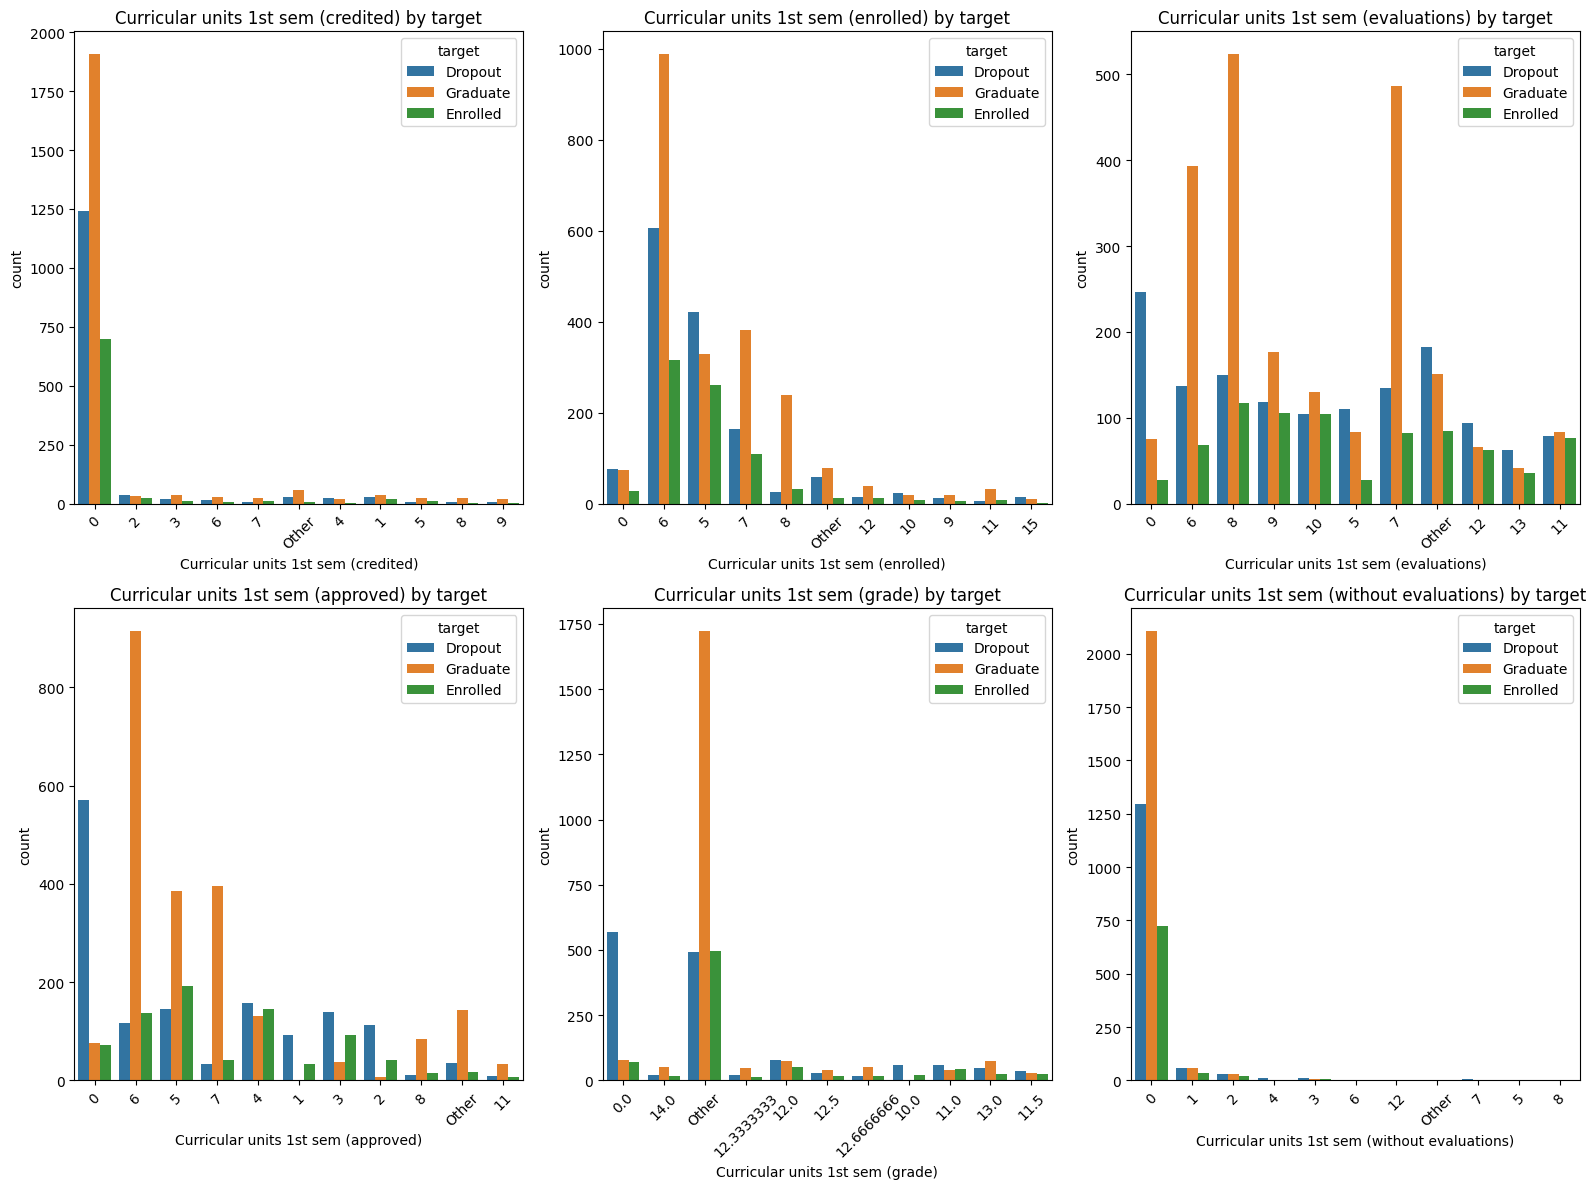

In [ ]:
plot_categories(sem1_cols)

# Pre-processing

### Removing second semester data

In [ ]:
sem_cols = [
    col for col in X.columns
    if '2nd' in col.lower()
]
X_filtered = X.drop(columns=sem_cols)

df = pd.concat([X_filtered, y], axis=1)
df.rename(columns={df.columns[-1]: "target"}, inplace=True)

### Removing sensitive columns

In [ ]:
df_clean_copy = pd.concat([X_filtered, y], axis=1)

X_filtered = X_filtered.drop(columns=["Nacionality"])
df = pd.concat([X_filtered, y], axis=1)
df.rename(columns={df.columns[-1]: "target"}, inplace=True)

X_filtered = X_filtered.drop(columns=["Gender"])
df = pd.concat([X_filtered, y], axis=1)
df.rename(columns={df.columns[-1]: "target"}, inplace=True)

X_filtered = X_filtered.drop(columns=["Age at enrollment"])
df = pd.concat([X_filtered, y], axis=1)
df.rename(columns={df.columns[-1]: "target"}, inplace=True)

### Encoding target variable

In [ ]:
# encode target
le = LabelEncoder()
df["target_enc"] = le.fit_transform(df["target"])
df.drop(columns=["target"], inplace=True)

print(f"\nEncoded target mapping:")
for i, label in enumerate(le.classes_):
    print(f"  {label} -> {i}")


Encoded target mapping:
  Dropout -> 0
  Enrolled -> 1
  Graduate -> 2


### Removing enrolled data

In [ ]:
# Remove "Enrolled" students (keeping only Dropout vs Graduate)
df_binary = df[df['target_enc'] != 1].copy()  # 1 is "Enrolled"
df_clean_copy = df_clean_copy[df_clean_copy['Target'] != 'Enrolled'].copy()
print(f"\nAfter removing 'Enrolled': {df_binary.shape}")

# Remap to binary: Dropout=0, Graduate=2 → Dropout=1, Graduate=0
# Dropout was encoded as 0, Graduate as 2
df_binary['target_binary'] = (df_binary['target_enc'] == 0).astype(int)

print(f"\nBinary target distribution:")
print(f"  Dropout (1): {(df_binary['target_binary'] == 1).sum()}")
print(f"  Graduate (0): {(df_binary['target_binary'] == 0).sum()}")

# Drop original target column
X_full = df_binary.drop(['target_enc', 'target_binary'], axis=1)
y_full = df_binary['target_binary']

print(f"\nFeatures shape: {X_full.shape}")
print(f"Number of features: {X_full.shape[1]}")


After removing 'Enrolled': (3630, 28)

Binary target distribution:
  Dropout (1): 1421
  Graduate (0): 2209

Features shape: (3630, 27)
Number of features: 27


### Creating pipeline for one-hot encoding and scaling


In [ ]:
continuous_features = [
    'Admission grade',
    'Previous qualification (grade)',
    'Curricular units 1st sem (credited)',
    'Curricular units 1st sem (enrolled)',
    'Curricular units 1st sem (evaluations)',
    'Curricular units 1st sem (approved)',
    'Curricular units 1st sem (grade)',
    'Unemployment rate',
    'Inflation rate',
    'GDP'
]

categorical_features = [
    c for c in X_full.columns
    if c not in continuous_features
]

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), continuous_features),
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), categorical_features)
    ]
)

# Model

### Defining base models to test

In [ ]:
base_models = {
    'LogisticRegression': LogisticRegression(max_iter=1000, class_weight='balanced', random_state=1),
    'DecisionTree': DecisionTreeClassifier(random_state=1, class_weight='balanced', max_depth=10),
    'RandomForest': RandomForestClassifier(n_estimators=200, class_weight='balanced', random_state=1, n_jobs=-1),
}

### Defining stacking classifier

In [ ]:
stacking = StackingClassifier(
    estimators=list(base_models.items()),
    final_estimator=LogisticRegression(max_iter=1000, class_weight='balanced', random_state=1),
    cv=5,
    n_jobs=-1
)

base_models['StackingClassifier'] = stacking

### Cross-validation setup

In [ ]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=1)

scoring = {
    'accuracy': 'accuracy',
    'dropout_recall': make_scorer(recall_score, pos_label=1),
    'f1_macro': 'f1_macro'
}

### Training

In [ ]:
results = []

for name, model in base_models.items():
    pipeline = Pipeline([
        ('preprocessor', preprocessor),
        ('model', model)
    ])

    cv_results = cross_validate(
        pipeline,
        X_full,
        y_full,
        cv=cv,
        scoring=scoring,
        n_jobs=-1,
        return_train_score=False
    )

    results.append({
        'model': name,
        'accuracy': cv_results['test_accuracy'].mean(),
        'dropout_recall': cv_results['test_dropout_recall'].mean(),
        'f1_macro': cv_results['test_f1_macro'].mean()
    })

In [ ]:
results_df = pd.DataFrame(results).sort_values(
    by=['dropout_recall', 'f1_macro', 'accuracy'],
    ascending=False
)

print(results_df.to_string(index=False))

             model  accuracy  dropout_recall  f1_macro
LogisticRegression  0.882369        0.838836  0.876062
      RandomForest  0.880992        0.783249  0.871773
      DecisionTree  0.855647        0.776909  0.846274


In [ ]:
lr_model = base_models['LogisticRegression']

lr_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', lr_model)
])
lr_pipeline.fit(X_full, y_full)

y_pred = lr_pipeline.predict(X_full)
cm = confusion_matrix(y_full, y_pred)
print("Confusion Matrix:\n", cm)

Confusion Matrix:
 [[2048  161]
 [ 196 1225]]



Logistic Regression Coefficients (sorted by importance):
                                               feature  coefficient
              num__Curricular units 1st sem (approved)    -3.666126
                        cat__Tuition fees up to date_1    -2.654342
                                       cat__Course_171    -1.740025
                                      cat__Course_9853     1.699735
              num__Curricular units 1st sem (enrolled)     1.462882
 cat__Curricular units 1st sem (without evaluations)_5    -1.421307
                                      cat__Course_9119     1.361618
                              cat__Application mode_15    -1.257836
                        cat__Mother's qualification_34     1.252650
                           cat__Father's occupation_90     1.155727
                        cat__Father's qualification_22     1.129114
                                         cat__Debtor_1     1.045367
                         cat__Previous qualification_2    

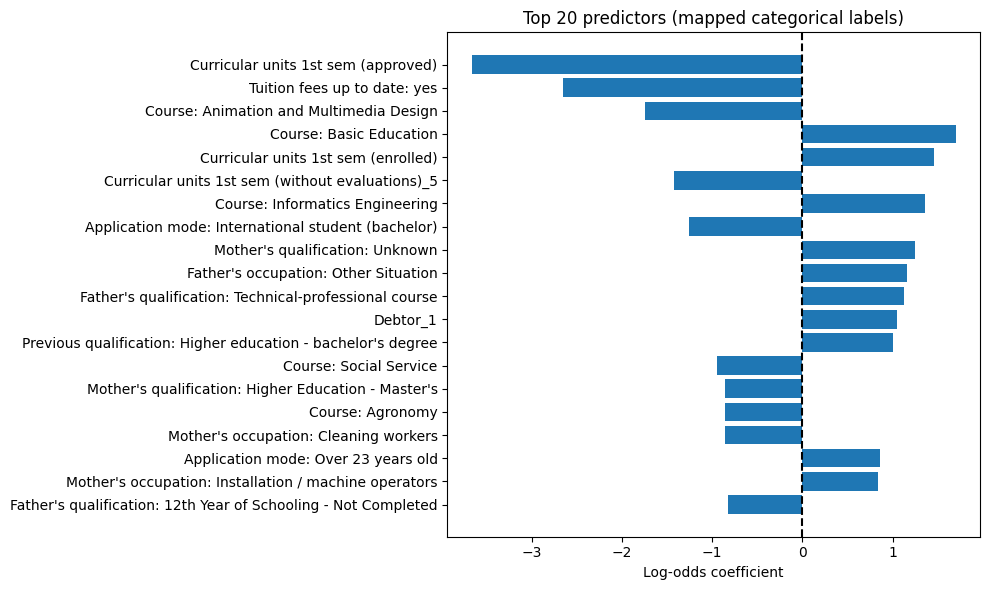

In [ ]:
lr_model = lr_pipeline.named_steps['model']
feature_names = lr_pipeline.named_steps['preprocessor'].get_feature_names_out()
coefficients = lr_model.coef_[0]

# Create a DataFrame with absolute value for sorting
coef_df = pd.DataFrame({
    'feature': feature_names,
    'coefficient': coefficients,
    'abs_coefficient': np.abs(coefficients)
})

# Sort by absolute value descending
coef_df_sorted = coef_df.sort_values(by='abs_coefficient', ascending=False)

print("\nLogistic Regression Coefficients (sorted by importance):")
print(coef_df_sorted[['feature', 'coefficient']].to_string(index=False))

def map_features(coef_df, value_maps):
    mapped_features = []

    for _, row in coef_df.iterrows():
        feat = row["feature"]
        coef = row["coefficient"]

        if feat.startswith("cat__"):
            # cat__Variable_123
            m = re.match(r"cat__(.+)_(\d+)$", feat)
            if m:
                var_name, code = m.groups()
                code = int(code)
                if var_name in value_maps:
                    label = value_maps[var_name].get(code, f"{var_name}_{code}")
                    mapped_features.append(f"{var_name}: {label}")
                else:
                    mapped_features.append(f"{var_name}_{code}")
            else:
                # fallback for unusual cat__ names without numeric suffix
                mapped_features.append(feat.replace("cat__", ""))
        elif feat.startswith("num__"):
            # numeric feature: keep as-is but remove prefix if desired
            mapped_features.append(feat.replace("num__", ""))
        else:
            # leave anything else unchanged
            mapped_features.append(feat)

    coef_df = coef_df.copy()
    coef_df["mapped_feature"] = mapped_features
    return coef_df

coef_df_mapped = map_features(coef_df, categorical_value_maps)


import matplotlib.pyplot as plt
top20 = coef_df_mapped.assign(abs_coef=coef_df_mapped["coefficient"].abs()).sort_values("abs_coef", ascending=False).head(20)

plt.figure(figsize=(10,6))
plt.barh(top20["mapped_feature"], top20["coefficient"])
plt.axvline(0, color='black', linestyle='--')
plt.gca().invert_yaxis()
plt.xlabel("Log-odds coefficient")
plt.title("Top 20 predictors (mapped categorical labels)")
plt.tight_layout()
plt.show()


# Fairness metrics

**Selecting fairness metrics:**

- Demographic parity not ideal: there might be differences in risks of different groups (either over-flag low risk groups or under-flag high risk groups)
- Equalized odds: same chance of catching at risk students, as well as false positive rate (does not matter that much, since false positives are not a big issue)
- **Equal opportunity**: best choice, equal true positive rate (recall) across groups, meaning that regardless of group we have the same chance of catching true positives

#### Initialising the functions

In [ ]:
def plot_confusion_matrices(cms, label_map, group_labels=("Overall", "Privileged", "Unprivileged"), cmap=plt.cm.Blues):

    labels = sorted(label_map.keys())
    display_labels = [label_map[l] for l in labels]

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    for i, cm in enumerate(cms):
        cm_percent = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100
        disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=display_labels)
        disp.plot(cmap=cmap, ax=axes[i], colorbar=False)
        axes[i].set_title(group_labels[i])

    plt.tight_layout()
    plt.show()

def get_general_metrics(preds, preds_unpriv, preds_priv, y, y_unpriv, y_priv, unpriv_label, priv_label):
    total_positive = (preds == 1).sum()
    total_negative = (preds == 0).sum()
    pos_unpriv = (preds_unpriv == 1).sum()
    pos_priv = (preds_priv == 1).sum()
    neg_unpriv = (preds_unpriv == 0).sum()
    neg_priv = (preds_priv == 0).sum()

    # Dropped out (pred=1) prediction distribution
    print(
        f"Total dropped out predictions (pred=1 -> Dropped out): {total_positive} \n"
        f"{unpriv_label}: {pos_unpriv} "
        f"({round(pos_unpriv/total_positive*100, 2)}%) \n"
        f"{priv_label}: {pos_priv} "
        f"({round(pos_priv/total_positive*100, 2)}%)"
    )

    # Favorable predictions (pred=0)
    print(
        f"\nTotal graduate predictions (pred=0 -> Graduated): {total_negative} \n"
        f"{unpriv_label}: {neg_unpriv} "
        f"({round(neg_unpriv/total_negative*100, 2)}%) \n"
        f"{priv_label}: {neg_priv} "
        f"({round(neg_priv/total_negative*100, 2)}%)"
    )

    # Accuracy
    overall_acc = round((preds == y).mean()*100, 2)
    acc_unpriv = round((preds_unpriv == y_unpriv).mean()*100, 2)
    acc_priv = round((preds_priv == y_priv).mean()*100, 2)

    print(
        f"\nAccuracy: Overall {overall_acc}% \n"
        f"{unpriv_label}: {acc_unpriv}% \n"
        f"{priv_label}: {acc_priv}%"
    )

def get_recall(cm_unpriv, cm_priv, cm_overall, unpriv_label, priv_label, print_):
    def safe_tpr(cm):
        return cm[1, 1] / cm[1].sum() if cm[1].sum() > 0 else 0.0

    tpr_overall = round(safe_tpr(cm_overall), 4)
    tpr_unpriv = round(safe_tpr(cm_unpriv), 4)
    tpr_priv = round(safe_tpr(cm_priv), 4)

    if print_:
        print("\nTrue Positive Rate (Recall):")
        print(f"Overall: {tpr_overall}")
        print(f"{unpriv_label}: {tpr_unpriv}")
        print(f"{priv_label}: {tpr_priv}")

    return {
        "TPR_overall": tpr_overall,
        "TPR_unpriv": tpr_unpriv,
        "TPR_priv": tpr_priv,
    }


#  Fairness evaluation
def get_stats(X, y, preds, sa_name, priv_value, priv_label, unpriv_label, display_labels):

    # Split by protected attribute
    priv_mask = X[sa_name] == priv_value
    y_priv, preds_priv = y[priv_mask], preds[priv_mask]
    y_unpriv, preds_unpriv = y[~priv_mask], preds[~priv_mask]

    # Confusion matrices
    cm_total = confusion_matrix(y, preds)
    cm_unpriv = confusion_matrix(y_unpriv, preds_unpriv)
    cm_priv = confusion_matrix(y_priv, preds_priv)

    print("\n===========================================================")
    print("        MODEL FAIRNESS EVALUATION")
    print("===========================================================\n")
    get_general_metrics(preds, preds_unpriv, preds_priv, y, y_unpriv, y_priv, unpriv_label, priv_label)
    get_recall(cm_unpriv, cm_priv, cm_total, unpriv_label, priv_label, print_=True)
    print("\n===========================================================\n")
    plot_confusion_matrices(
        [cm_total, cm_priv, cm_unpriv],
        display_labels,
        group_labels=("Overall", priv_label, unpriv_label)
      )


def fairness_metrics_by_category(X, y, preds, col):
    rows = []

    for val in X[col].unique():
        mask = X[col] == val
        n = mask.sum()

        cm = confusion_matrix(y[mask], preds[mask], labels=[0, 1])

        acc = (y[mask] == preds[mask]).mean()
        tpr = cm[1, 1] / cm[1].sum() if cm[1].sum() else np.nan
        fpr = cm[0, 1] / cm[0].sum() if cm[0].sum() else np.nan

        label_str = categorical_value_maps.get(col, {}).get(val, str(val))

        rows.append({
            f"{col} id": val,
            col: label_str,
            "n": n,
            "accuracy": round(acc, 4),
            "recall_tpr": round(tpr, 4),
            "false_positive_rate": round(fpr, 4)
        })

    return pd.DataFrame(rows).sort_values("n", ascending=False).reset_index(drop=True)

### Gender


        MODEL FAIRNESS EVALUATION

Total dropped out predictions (pred=1 -> Dropped out): 1386 
Female: 699 (50.43%) 
Male: 687 (49.57%)

Total graduate predictions (pred=0 -> Graduated): 2244 
Female: 1682 (74.96%) 
Male: 562 (25.04%)

Accuracy: Overall 90.17% 
Female: 90.3% 
Male: 89.91%

True Positive Rate (Recall):
Overall: 0.8621
Female: 0.825
Male: 0.9001




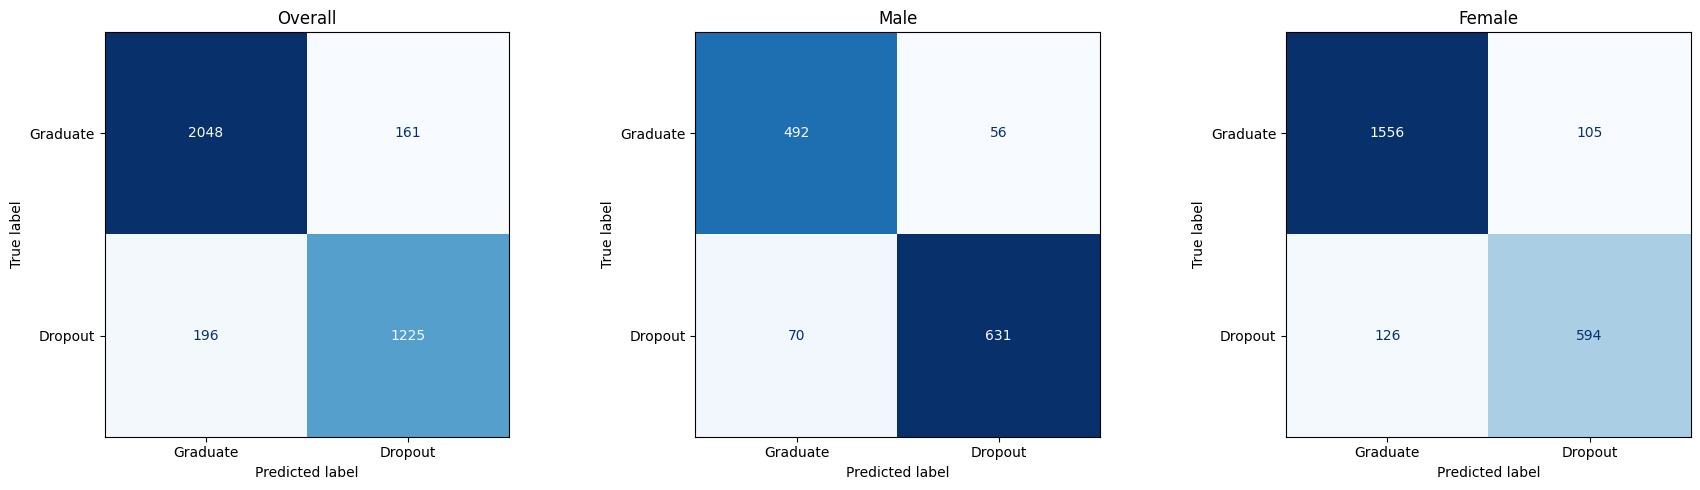

In [ ]:
get_stats(df_clean_copy, y_full, y_pred, 'Gender', 1, 'Male', 'Female', {0.0: 'Graduate', 1.0: 'Dropout'})

### International students


        MODEL FAIRNESS EVALUATION

Total dropped out predictions (pred=1 -> Dropped out): 1386 
Portugese: 1351 (97.47%) 
International: 35 (2.53%)

Total graduate predictions (pred=0 -> Graduated): 2244 
Portugese: 2193 (97.73%) 
International: 51 (2.27%)

Accuracy: Overall 90.17% 
Portugese: 90.24% 
International: 87.21%

True Positive Rate (Recall):
Overall: 0.8621
Portugese: 0.8618
International: 0.875




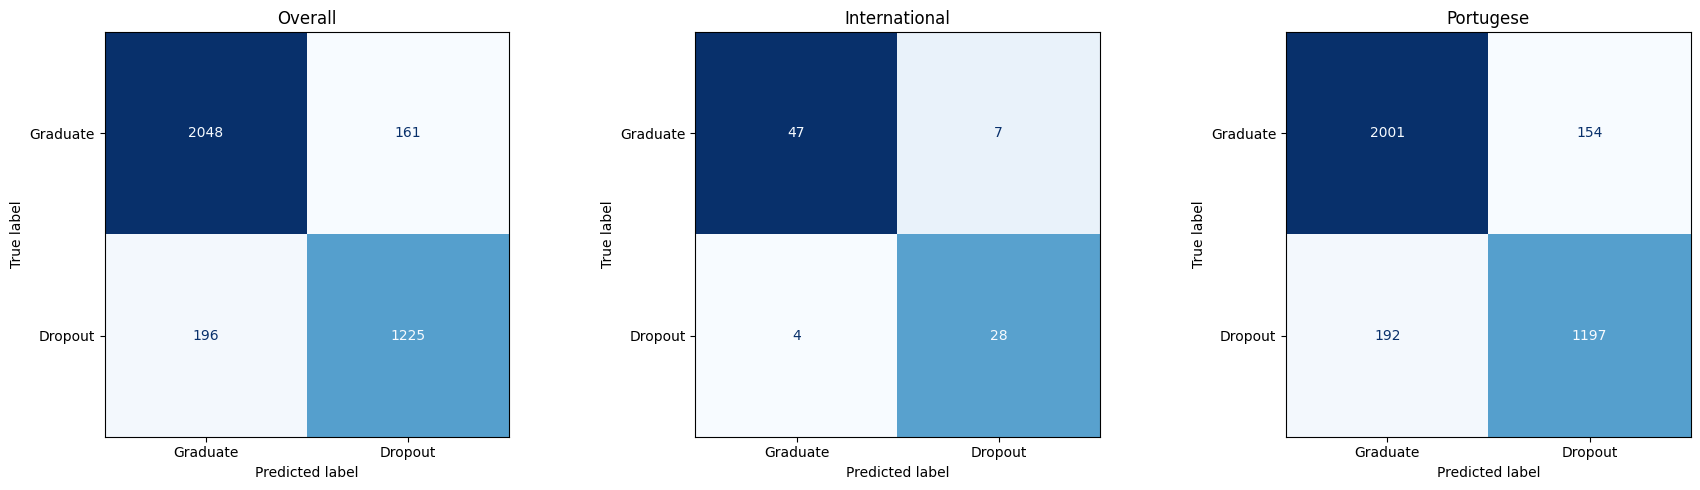

In [ ]:
get_stats(X_full, y_full, y_pred, 'International', 1, 'International', 'Portugese', {0.0: 'Graduate', 1.0: 'Dropout'})

### Scholarship holders


        MODEL FAIRNESS EVALUATION

Total dropped out predictions (pred=1 -> Dropped out): 1273 
No scholarship: 1101 (86.49%) 
Scholarship: 172 (13.51%)

Total graduate predictions (pred=0 -> Graduated): 2357 
No scholarship: 1560 (66.19%) 
Scholarship: 797 (33.81%)

Accuracy: Overall 88.26% 
No scholarship: 88.65% 
Scholarship: 87.2%

True Positive Rate (Recall):
Overall: 0.798
No scholarship: 0.8104
Scholarship: 0.6791




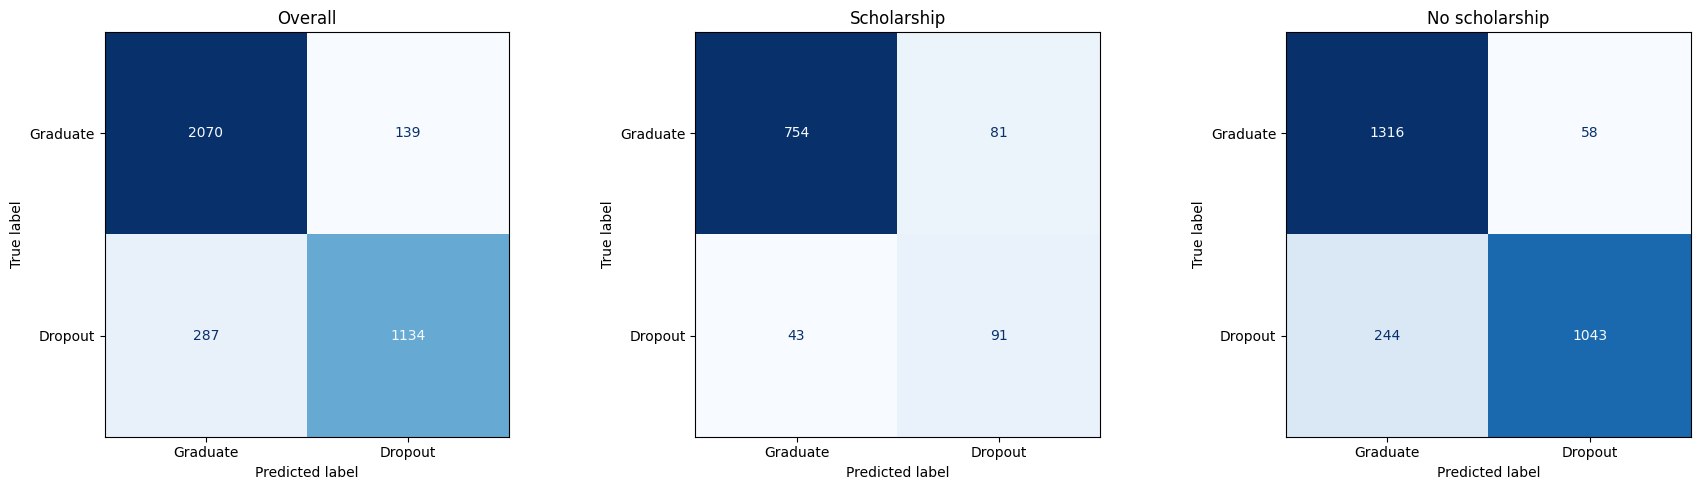

In [ ]:
get_stats(X_full, y_full, y_pred, 'Scholarship holder', 1, 'Scholarship', 'No scholarship', {0.0: 'Graduate', 1.0: 'Dropout'})

In case of the scholarships we can see that for scholarship holders our model is not able to reliably predict student's at risk (only 55% recall, whereas it has around 89% for non-scholarship holders)

### Educational special needs


        MODEL FAIRNESS EVALUATION

Total dropped out predictions (pred=1 -> Dropped out): 1386 
No special needs: 1369 (98.77%) 
Special needs: 17 (1.23%)

Total graduate predictions (pred=0 -> Graduated): 2244 
No special needs: 2221 (98.98%) 
Special needs: 23 (1.02%)

Accuracy: Overall 90.17% 
No special needs: 90.17% 
Special needs: 90.0%

True Positive Rate (Recall):
Overall: 0.8621
No special needs: 0.8618
Special needs: 0.8824




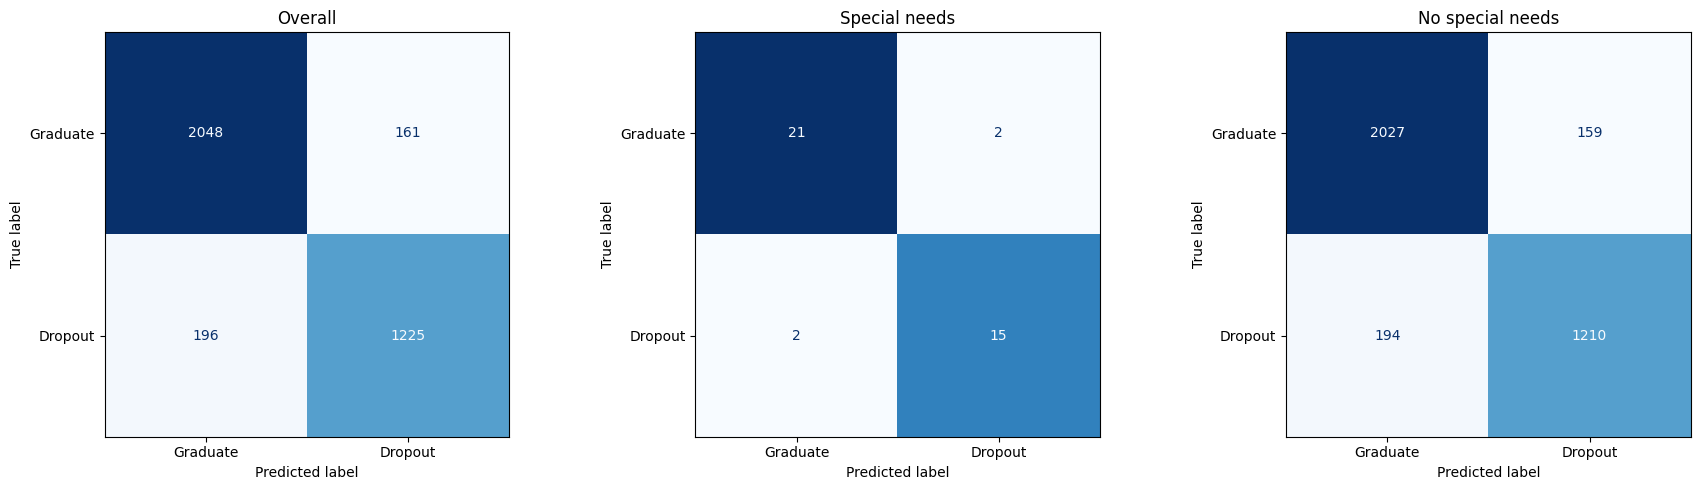

In [ ]:
get_stats(X_full, y_full, y_pred, 'Educational special needs', 1, 'Special needs', 'No special needs', {0.0: 'Graduate', 1.0: 'Dropout'})

### Debt & Tuition fees paid on time


        MODEL FAIRNESS EVALUATION

Total dropped out predictions (pred=1 -> Dropped out): 1386 
No debtor: 1058 (76.33%) 
Debtor: 328 (23.67%)

Total graduate predictions (pred=0 -> Graduated): 2244 
No debtor: 2159 (96.21%) 
Debtor: 85 (3.79%)

Accuracy: Overall 90.17% 
No debtor: 90.02% 
Debtor: 91.28%

True Positive Rate (Recall):
Overall: 0.8621
No debtor: 0.8323
Debtor: 0.9679




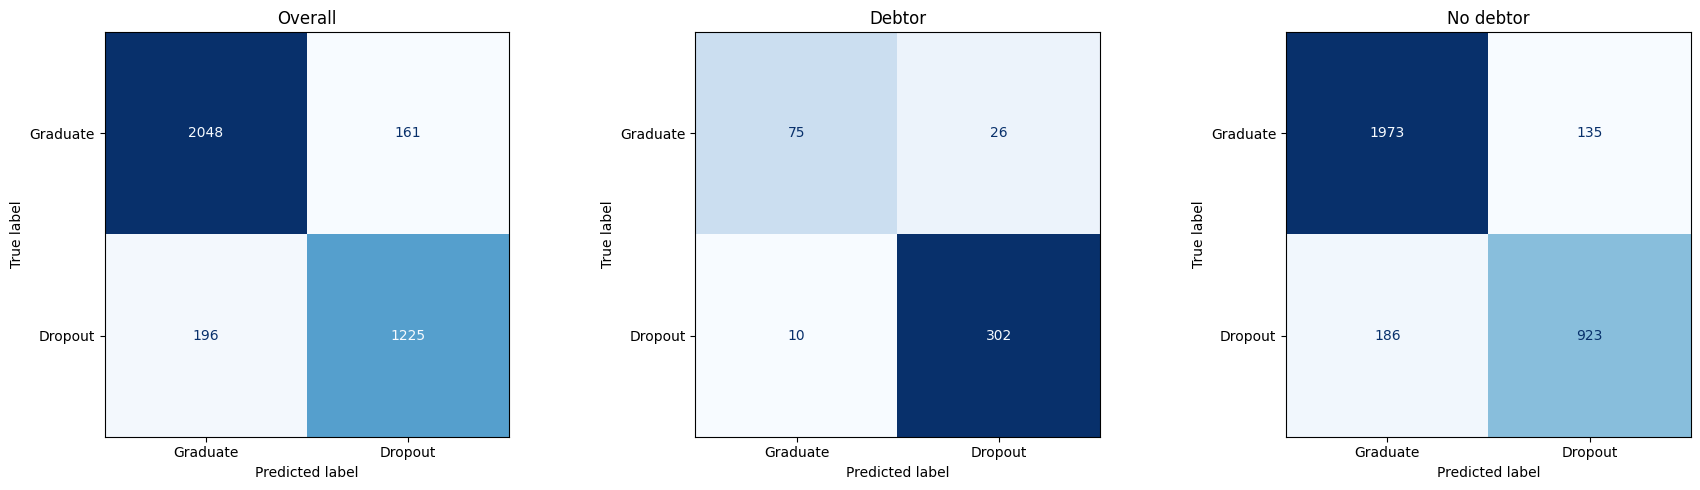

In [ ]:
get_stats(X_full, y_full, y_pred, 'Debtor', 1, 'Debtor', 'No debtor', {0.0: 'Graduate', 1.0: 'Dropout'})


        MODEL FAIRNESS EVALUATION

Total dropped out predictions (pred=1 -> Dropped out): 1386 
Not paid: 473 (34.13%) 
Up to date: 913 (65.87%)

Total graduate predictions (pred=0 -> Graduated): 2244 
Not paid: 13 (0.58%) 
Up to date: 2231 (99.42%)

Accuracy: Overall 90.17% 
Not paid: 96.3% 
Up to date: 89.22%

True Positive Rate (Recall):
Overall: 0.8621
Not paid: 0.9978
Up to date: 0.7977




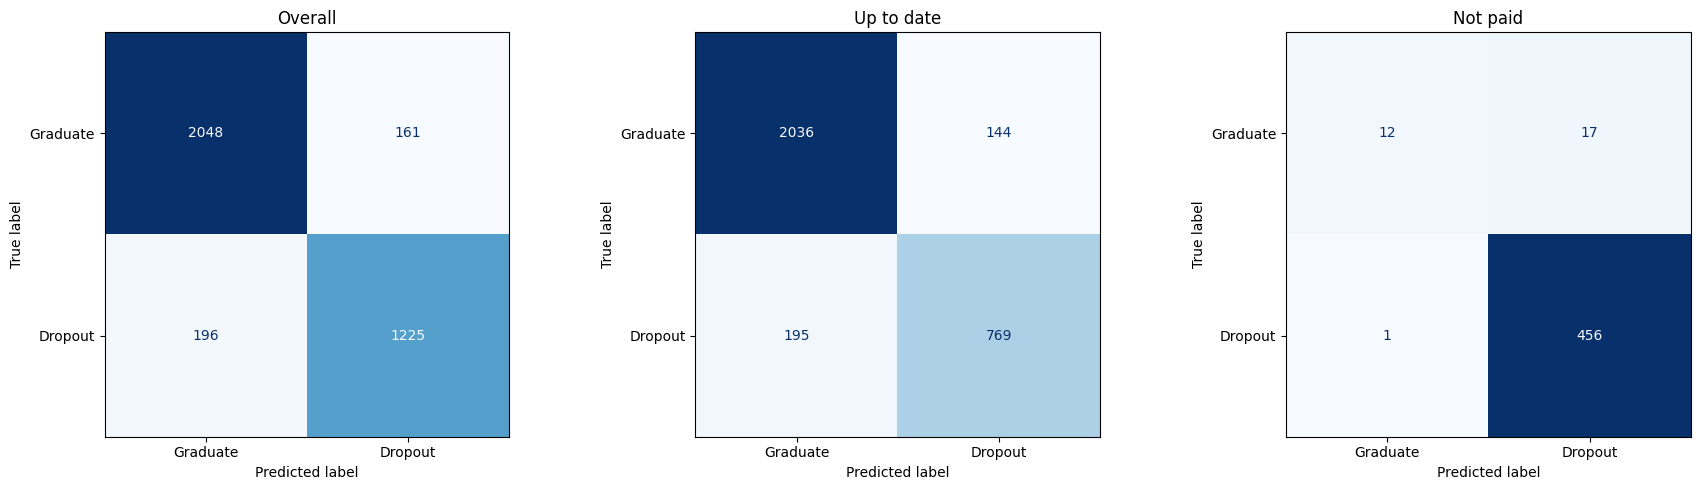

In [ ]:
get_stats(X_full, y_full, y_pred, 'Tuition fees up to date', 1, 'Up to date', 'Not paid', {0.0: 'Graduate', 1.0: 'Dropout'})

### Marital status

In [ ]:
fairness_metrics_by_category(X_full, y_full, y_pred, "Marital Status")

,Marital Status id,Marital Status,n,accuracy,recall_tpr,false_positive_rate
0,1,single,3199,0.9003,0.8505,0.0705
1,2,married,327,0.9113,0.9162,0.0946
2,4,divorced,75,0.8933,0.9286,0.1515
3,5,facto union,22,0.9545,0.9091,0.0000
4,6,legally separated,5,1.0000,1.0000,0.0000
5,3,widower,2,1.0000,1.0000,0.0000


### Parent's occupations and qualifications

In [ ]:
fairness_metrics_by_category(X_full, y_full, y_pred, "Father's occupation")

,Father's occupation id,Father's occupation,n,accuracy,recall_tpr,false_positive_rate
0,9,Unskilled Workers,847,0.8937,0.8483,0.0782
1,7,"Skilled workers in Industry, Construction, Cra...",555,0.9027,0.8152,0.0539
2,5,Personal Services / Security / Sellers,409,0.9022,0.8446,0.0651
3,3,Intermediate Technicians,321,0.8723,0.8070,0.0918
4,4,Administrative staff,312,0.8878,0.8849,0.1098
5,8,Installation / Machine operators / Assembly wo...,263,0.9354,0.8830,0.0355
6,10,Armed Forces Professions,212,0.8915,0.8471,0.0787
7,6,"Farmers / Skilled workers in Agriculture, Fish...",194,0.9278,0.8841,0.0480
8,2,Intellectual/Scientific specialists,147,0.9184,0.9000,0.0649
9,0,Student,125,0.8720,0.9268,0.2326


In [ ]:
fairness_metrics_by_category(X_full, y_full, y_pred, "Father's qualification")

,Father's qualification id,Father's qualification,n,accuracy,recall_tpr,false_positive_rate
0,37,Basic education 1st cycle (4th/5th year) or eq...,1010,0.9129,0.8843,0.0657
1,19,Basic Education 3rd Cycle or Equiv.,785,0.9006,0.8333,0.0653
2,1,Secondary Education - 12th Year or Eq.,732,0.8921,0.8541,0.0843
3,38,Basic Education 2nd Cycle (6th/7th/8th Year) o...,575,0.9061,0.8084,0.0539
4,3,Higher Education - Degree,220,0.8818,0.8444,0.0923
5,34,Unknown,109,0.8991,0.9383,0.2143
6,2,Higher Education - Bachelor's Degree,43,0.7907,0.8182,0.2381
7,12,Other - 11th Year of Schooling,34,0.9118,0.9286,0.1000
8,4,Higher Education - Master's,32,0.9062,0.8571,0.0556
9,5,Higher Education - Doctorate,15,0.9333,0.9000,0.0000


In [ ]:
fairness_metrics_by_category(X_full, y_full, y_pred, "Mother's occupation")

,Mother's occupation id,Mother's occupation,n,accuracy,recall_tpr,false_positive_rate
0,9,Unskilled workers,1313,0.9101,0.8592,0.0595
1,4,Administrative staff,670,0.8940,0.8347,0.0711
2,5,Personal services / sellers,436,0.8899,0.8397,0.0821
3,3,Intermediate Technicians,272,0.8897,0.8421,0.0847
4,2,Intellectual/Scientific specialists,240,0.8625,0.8431,0.1232
5,7,Skilled workers in industry,224,0.9241,0.8500,0.0347
6,0,Student,143,0.8462,0.8990,0.2727
7,1,Legislative/Executive managers,87,0.9540,0.9487,0.0417
8,6,Farmers / skilled workers,77,0.9091,0.8462,0.0588
9,90,Other situation,70,0.9429,0.9804,0.1579


In [ ]:
fairness_metrics_by_category(X_full, y_full, y_pred, "Mother's qualification")

,Mother's qualification id,Mother's qualification,n,accuracy,recall_tpr,false_positive_rate
0,1,Secondary Education - 12th Year or Eq.,865,0.9017,0.8400,0.0655
1,37,Basic education 1st cycle,840,0.9060,0.8877,0.0788
2,19,Basic Education 3rd Cycle or Equiv.,777,0.9112,0.8561,0.0593
3,38,Basic Education 2nd Cycle,471,0.9108,0.8143,0.0483
4,3,Higher Education - Degree,337,0.8665,0.8489,0.1212
5,34,Unknown,127,0.8740,0.9271,0.2903
6,2,Higher Education - Bachelor's Degree,60,0.8667,0.7500,0.0750
7,12,Other - 11th Year of Schooling,39,0.8718,0.8636,0.1176
8,4,Higher Education - Master's,34,0.9706,0.8750,0.0000
9,5,Higher Education - Doctorate,16,0.8750,0.8750,0.1250


### Daytime / evening attendance




        MODEL FAIRNESS EVALUATION

Total dropped out predictions (pred=1 -> Dropped out): 1386 
Daytime: 205 (14.79%) 
Evening: 1181 (85.21%)

Total graduate predictions (pred=0 -> Graduated): 2244 
Daytime: 203 (9.05%) 
Evening: 2041 (90.95%)

Accuracy: Overall 90.17% 
Daytime: 91.18% 
Evening: 90.04%

True Positive Rate (Recall):
Overall: 0.8621
Daytime: 0.9082
Evening: 0.8542




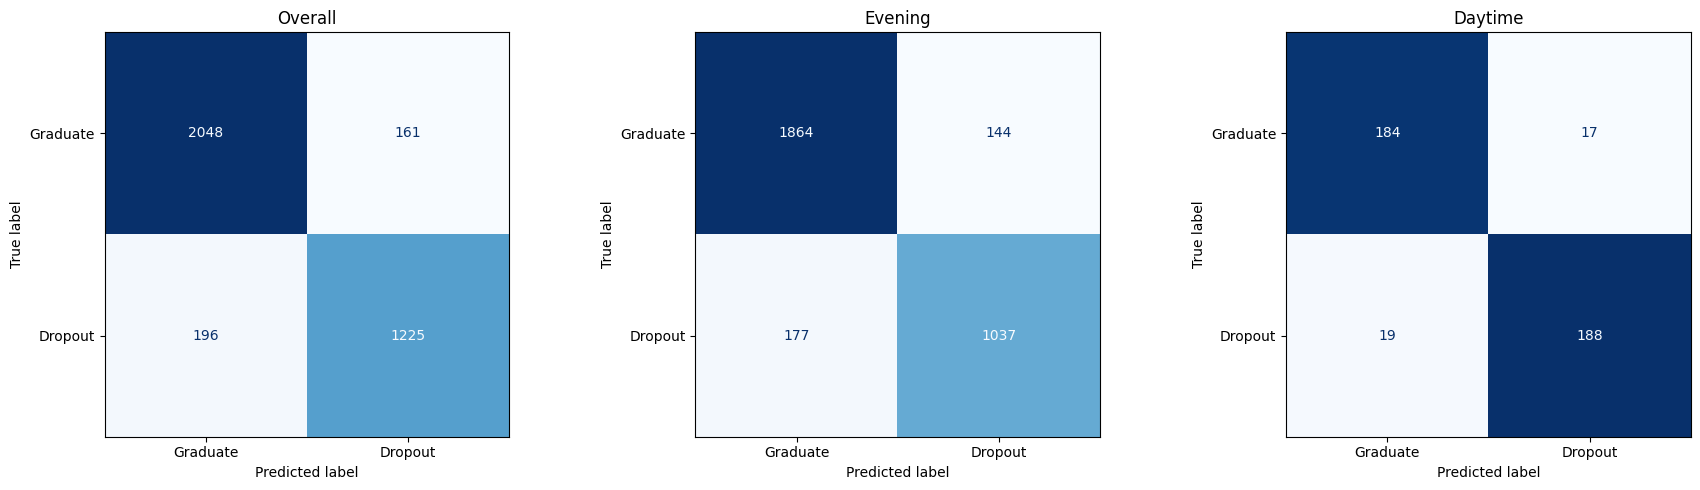

In [ ]:
get_stats(X_full, y_full, y_pred, 'Daytime/evening attendance', 1, 'Evening', 'Daytime', {0.0: 'Graduate', 1.0: 'Dropout'})

# Reweighing


        MODEL FAIRNESS EVALUATION

Total dropped out predictions (pred=1 -> Dropped out): 1273 
Disadvantaged Groups: 172 (13.51%) 
Other Groups: 1101 (86.49%)

Total graduate predictions (pred=0 -> Graduated): 2357 
Disadvantaged Groups: 797 (33.81%) 
Other Groups: 1560 (66.19%)

Accuracy: Overall 88.26% 
Disadvantaged Groups: 87.2% 
Other Groups: 88.65%

True Positive Rate (Recall):
Overall: 0.798
Disadvantaged Groups: 0.6791
Other Groups: 0.8104




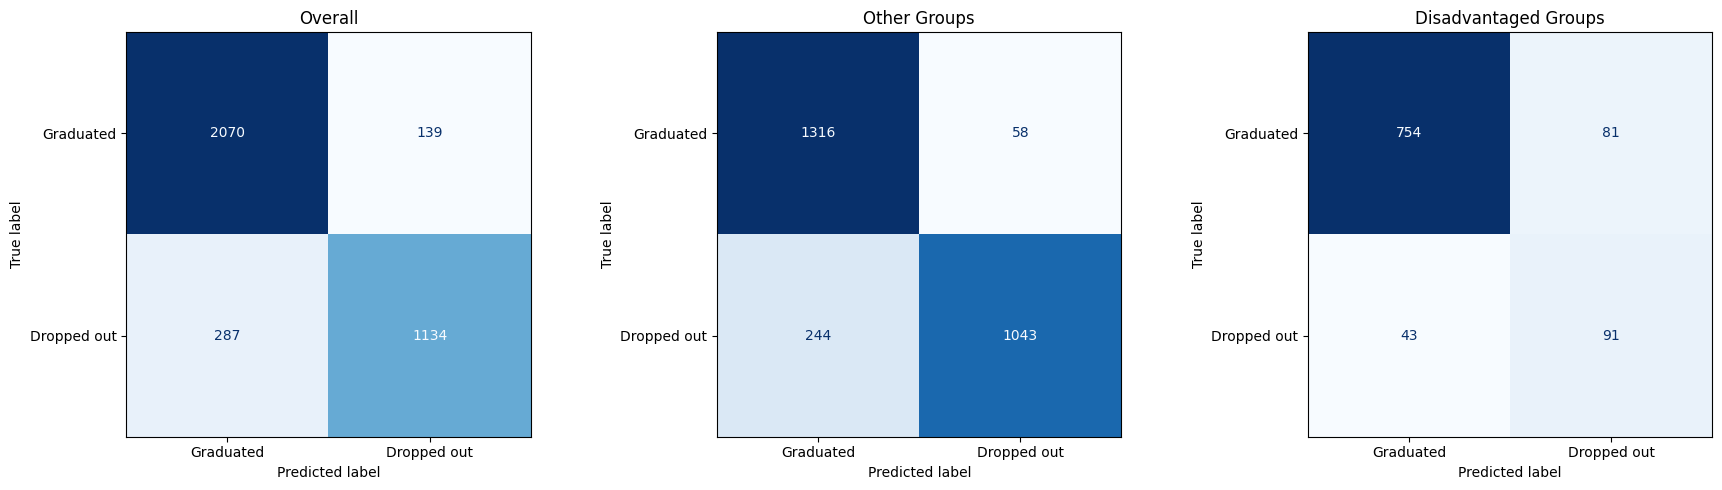


=== Cross-Validation Results ===
Accuracy: 0.8678 (+/- 0.0088)
Dropout Recall: 0.7833 (+/- 0.0115)
F1 Macro: 0.8586 (+/- 0.0086)


In [ ]:
def create_disadvantaged_column(X):
    return (
        X['Scholarship holder'].isin([1]) #|
        #X["Father's qualification"].isin([40]) |
        #X["Mother's qualification"].isin([40])
        ).astype(int)

X_full['is_disadvantaged'] = create_disadvantaged_column(X_full)

# Printing metrics before reweighing for comparison
get_stats(
    X_full,
    y_full,
    y_pred,
    sa_name='is_disadvantaged',
    priv_value=0,
    priv_label='Other Groups',
    unpriv_label='Disadvantaged Groups',
    display_labels={0: 'Graduated', 1: 'Dropped out'}
)

full_data = BinaryLabelDataset(
    df = pd.concat([X_full, y_full], axis=1),
    label_names=['target_binary'],
    protected_attribute_names=['is_disadvantaged'],
    favorable_label=1,
    unfavorable_label=0
)

dataset_transf_full = Reweighing(
    unprivileged_groups=[{'is_disadvantaged': 1}],
    privileged_groups=[{'is_disadvantaged': 0}]
).fit(full_data).transform(full_data)

instance_weights = dataset_transf_full.instance_weights

X_full = X_full.drop('is_disadvantaged', axis=1)

lr_model = LogisticRegression(max_iter=1000, random_state=1)
lr_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', lr_model)
])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=1)

scoring = {
    'accuracy': 'accuracy',
    'dropout_recall': make_scorer(recall_score, pos_label=1),
    'f1_macro': 'f1_macro'
}

cv_results = cross_validate(
    lr_pipeline,
    X_full,
    y_full,
    cv=cv,
    scoring=scoring,
    n_jobs=-1,
    return_train_score=False,
    params={'model__sample_weight': instance_weights}
)

print("\n=== Cross-Validation Results ===")
print(f"Accuracy: {cv_results['test_accuracy'].mean():.4f} (+/- {cv_results['test_accuracy'].std():.4f})")
print(f"Dropout Recall: {cv_results['test_dropout_recall'].mean():.4f} (+/- {cv_results['test_dropout_recall'].std():.4f})")
print(f"F1 Macro: {cv_results['test_f1_macro'].mean():.4f} (+/- {cv_results['test_f1_macro'].std():.4f})")




        MODEL FAIRNESS EVALUATION

Total dropped out predictions (pred=1 -> Dropped out): 1273 
Disadvantaged Groups: 178 (13.98%) 
Other Groups: 1095 (86.02%)

Total graduate predictions (pred=0 -> Graduated): 2357 
Disadvantaged Groups: 801 (33.98%) 
Other Groups: 1556 (66.02%)

Accuracy: Overall 88.26% 
Disadvantaged Groups: 87.03% 
Other Groups: 88.72%

True Positive Rate (Recall):
Overall: 0.798
Disadvantaged Groups: 0.6835
Other Groups: 0.8105




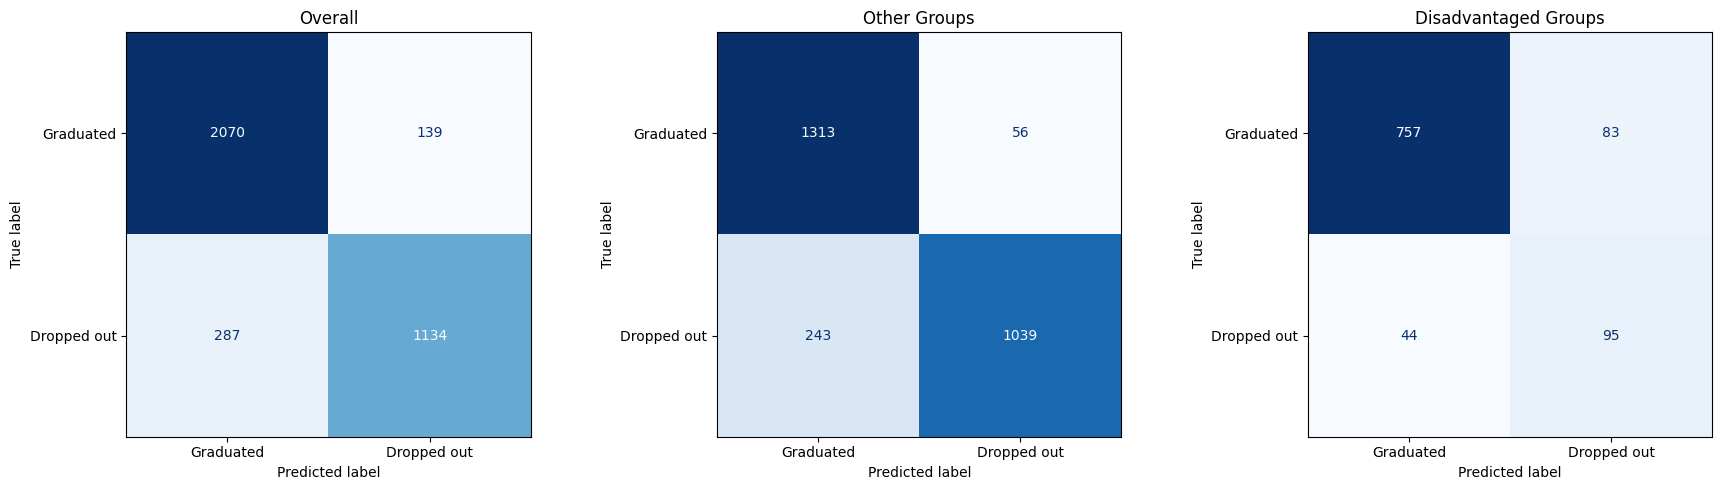

In [ ]:
lr_final = Pipeline([
    ('preprocessor', preprocessor),
    ('model', LogisticRegression(max_iter=1000, random_state=1))
])

lr_final.fit(X_full, y_full, model__sample_weight=instance_weights)

# Evaluate
y_pred = lr_final.predict(X_full)

X_full['is_disadvantaged'] = create_disadvantaged_column(X_full)

get_stats(
    X_full,
    y_full,
    y_pred,
    sa_name='is_disadvantaged',
    priv_value=0,
    priv_label='Other Groups',
    unpriv_label='Disadvantaged Groups',
    display_labels={0: 'Graduated', 1: 'Dropped out'}
)